In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
import warnings

2026-09-30 01:44:44.001534: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-30 01:44:44.310582: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
warnings.filterwarnings('ignore')

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-09-30 01:44:48.504312: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-30 01:44:49.684686: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-30 01:44:49.688391: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [ ]:
with h5py.File('binding_data_cl.h5','r') as h5f, h5py.File('Protein_data_cl.h5', 'r') as h5p:       # Loading Data
    x = h5f['features'][:]
    y = h5f['target'][:]
    z = h5p['BindingDB Target Chain Sequence 1'][:]

x_lig_train, x_lig_test, x_prot_train, x_prot_test, y_train, y_test = train_test_split(x,z,y, test_size = 0.2, random_state = 42)

In [6]:
import gc
del x, y, z
gc.collect()

20

In [ ]:
def Dual_input_model():
    ligand_input = layers.Input(shape = (2053,), name = 'ligand_input')           # Ligand Branch
    x = layers.Dense(1024, activation = 'elu')(ligand_input)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(512, activation = 'elu')(x)
    x = layers.BatchNormalization()(x)
    ligand_branch = layers.Dropout(0.3)(x)

    protein_input = layers.Input(shape = (400,), name = 'protein_input')         # Protein Branch
    y = layers.Dense(1024, activation = 'elu')(protein_input)
    y = layers.BatchNormalization()(y)
    y = layers.Dropout(0.4)(y)

    y = layers.Dense(512, activation = 'elu')(y)
    y = layers.BatchNormalization()(y) 
    protein_branch = layers.Dropout(0.3)(y)


    concat = layers.Concatenate()([ligand_branch, protein_branch])       #Concatatenating outputs of both branch
    interact = layers.Multiply()([ligand_branch, protein_branch])        # Multiplying outputs of both branch
    combined = layers.Concatenate()([concat, interact])                  # Concatenating the concatenation and multiplication of both branch outputs to simulate interaction.

    # Deep Layers to understand Interactions.

    z = layers.Dense(2048, activation = 'swish')(combined)               
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(1024, activation = 'swish')(z)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(512, activation = 'swish')(z)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.4)(z)

    z = layers.Dense(256, activation = 'swish')(z)
    z = layers.BatchNormalization()(z)
    z = layers.Dropout(0.3)(z)


    output = layers.Dense(1, name = 'pki_prediction')(z)

    model = Model(inputs = [ligand_input, protein_input], outputs = output)

    return model

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
reduced_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 10,
    min_lr = 1e-9,
    verbose = 1
)

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    restore_best_weights = True
)

lr_decay = CosineDecay(
    initial_learning_rate = 1e-3,
    decay_steps = 300 * (len(x_lig_train) // 512),
    alpha = 1e-6
)

In [ ]:
# Epochs and Batch size

epochs = 300
BATCH_SIZE = 512

In [10]:
model = Dual_input_model()
model.compile(optimizer = AdamW(
    learning_rate = lr_decay,
    weight_decay = 1e-2,
), loss = 'mse')
model.summary()

2026-09-30 01:45:21.460243: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-30 01:45:21.463249: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-30 01:45:21.465584: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ligand_input        │ (None, 2053)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_input       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │  2,103,296 │ ligand_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024)      │    410,624 │ protein_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024)      │      4,096 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    524,800 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    524,800 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024)      │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 512)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1536)      │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2048)      │  3,147,776 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 2048)      │          0 │ batch_normalizat

 Total params: 9,493,505 (36.21 MB)

 Trainable params: 9,479,681 (36.16 MB)

 Non-trainable params: 13,824 (54.00 KB)

In [11]:
history = model.fit(
    x = {
        'ligand_input' : x_lig_train,
        'protein_input' : x_prot_train
    },
    y = y_train,
    validation_data = ({
                'ligand_input' : x_lig_test,
                'protein_input' : x_prot_test
    }, y_test),
    batch_size = BATCH_SIZE,
    epochs = epochs,
    callbacks = [early_stop]
)

Epoch 1/300


I0000 00:00:1790712926.923483   54734 service.cc:145] XLA service 0x78c39802fd50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790712926.923793   54734 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-09-30 01:45:27.068086: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-30 01:45:27.524974: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1790712931.828593   54857 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1415', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1790712932.046195   54858 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_6476', 8 bytes spill stores, 8 bytes spill loads

I00

 22/873 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 51.2538 

I0000 00:00:1790712937.403409   54734 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


866/873 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17.6285

I0000 00:00:1790712948.500288   55061 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1415', 456 bytes spill stores, 540 bytes spill loads

I0000 00:00:1790712948.593432   55068 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1415', 124 bytes spill stores, 124 bytes spill loads

I0000 00:00:1790712948.676791   55060 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1415', 144 bytes spill stores, 144 bytes spill loads

I0000 00:00:1790712948.796723   55062 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_6247', 180 bytes spill stores, 180 bytes spill loads

I0000 00:00:1790712949.468180   55065 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1415', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1790712949

873/873 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.5492

I0000 00:00:1790712955.693688   55296 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_118', 124 bytes spill stores, 124 bytes spill loads

I0000 00:00:1790712955.727734   55287 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_118', 80 bytes spill stores, 84 bytes spill loads

I0000 00:00:1790712955.769502   55292 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_118', 144 bytes spill stores, 144 bytes spill loads

I0000 00:00:1790712956.047668   55299 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_118', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1790712956.061518   55291 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_118', 520 bytes spill stores, 520 bytes spill loads

I0000 00:00:1790712956.177582

873/873 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - loss: 7.7115 - val_loss: 1.5281
Epoch 2/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.9984 - val_loss: 1.1873
Epoch 3/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.4174 - val_loss: 1.0351
Epoch 4/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.1668 - val_loss: 0.9731
Epoch 5/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 1.0230 - val_loss: 0.8720
Epoch 6/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.9277 - val_loss: 0.8294
Epoch 7/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.8636 - val_loss: 0.8891
Epoch 8/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.8079 - val_loss: 0.8098
Epoch 9/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.7679 - val_loss: 0.8835
Epoch 10/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.7335 - val_loss: 0.7444
Epoch 11/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.7027 - val_loss: 0.7367
Epoch 12/300
873/873 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/st

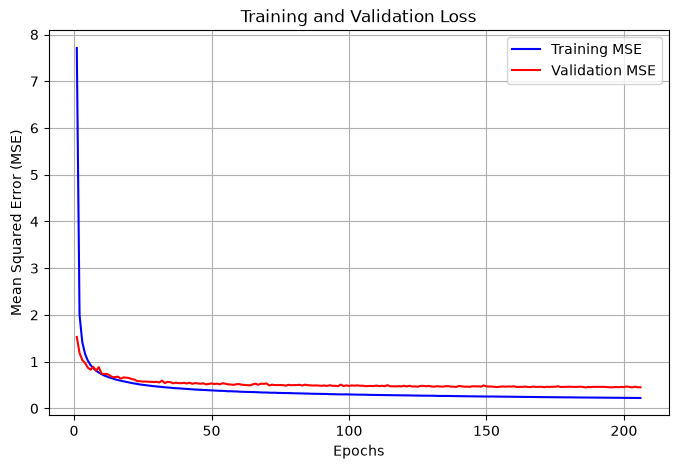

In [ ]:
import matplotlib.pyplot as plt

# Extracting loss values from the Keras history object

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'b-', label='Training MSE')
plt.plot(epochs, val_loss, 'r-', label='Validation MSE')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predicting
y_pred = model.predict([x_lig_test, x_prot_test] )

# Quantitative metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2*100:.4f}")

I0000 00:00:1790714443.531502   80631 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_112', 48 bytes spill stores, 52 bytes spill loads

I0000 00:00:1790714443.753621   80626 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_112', 12 bytes spill stores, 12 bytes spill loads



3464/3492 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step

I0000 00:00:1790714448.057257   80713 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_112', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1790714448.452939   80702 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_112', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1790714448.663337   80704 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_112', 4 bytes spill stores, 4 bytes spill loads



3492/3492 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Root Mean Squared Error (RMSE): 0.6701
Mean Absolute Error (MAE): 0.4485
R-squared (R2) Score: 82.1664
